In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
with open('results/full_run_3/simulation_results_groups_1_10_0.0.json', 'r') as f:
    data0 = json.load(f)

with open('results/full_run_3/simulation_results_groups_1_10_4.0.json', 'r') as f1:
    data4 = json.load(f1)

with open('results/full_run_3/simulation_results_groups_1_10_8.0.json', 'r') as f2:
    data8 = json.load(f2)

with open('results/full_run_3/simulation_results_groups_1_10_12.0.json', 'r') as f3:
    data12 = json.load(f3)

In [3]:
with open('simulation_resources/participant_attitudes.json', 'r') as f:
    participants = json.load(f)

groups = list(set([int(x.split("_")[1]) for x in data0.keys()]))
questions = list(set([(x.split("_")[2]) for x in data0.keys()]))

In [4]:
df = []
for participant in participants:
    pid = participant['id']
    groupid = participant['group']
    if groupid in groups:
        for question in questions:
            row = {}
            row['id'] = pid
            row["question"] = question
            row["before_attitude"] = participant['questions'][question]
            groupIndex = "Group_" + str(groupid) + "_" + question
            row["temp_0"] = data0[groupIndex]['rankings'][str(pid)]
            row["temp_4"] = data4[groupIndex]['rankings'][str(pid)]
            row["temp_8"] = data8[groupIndex]['rankings'][str(pid)]
            row["temp_12"] = data12[groupIndex]['rankings'][str(pid)]
            row["temp_0_arguments"] = data0[groupIndex]['arguments'][str(pid)]
            row["temp_4_arguments"] = data4[groupIndex]['arguments'][str(pid)]
            row["temp_8_arguments"] = data8[groupIndex]['arguments'][str(pid)]
            row["temp_12_arguments"] = data12[groupIndex]['arguments'][str(pid)]
            df.append(row)

df = pd.DataFrame(df)

In [5]:
question_df = pd.read_csv("clean_data/question_level_master_dataset.csv")
compare_df = df.merge(question_df, left_on=["id","question"], right_on=['ID',"Question"], how="left")
compare_df.drop(columns=["id","question","before_attitude","BeforeResponse","AfterResponse"], inplace=True)
compare_df.rename(columns={"after_attitude":"LLMNumber"}, inplace=True)

In [6]:
acceptable_range = list(range(0,11))

In [7]:
# filter out rows where LLMNumber, BeforeNumber, or AfterNumber is 77 98 or 99
compare_df = compare_df[compare_df["temp_0"].isin(acceptable_range)]
compare_df = compare_df[compare_df["temp_4"].isin(acceptable_range)]
compare_df = compare_df[compare_df["temp_8"].isin(acceptable_range)]
compare_df = compare_df[compare_df["temp_12"].isin(acceptable_range)]
compare_df = compare_df[compare_df["AfterNumber"].isin(acceptable_range)]
compare_df = compare_df[compare_df["BeforeNumber"].isin(acceptable_range)]

In [8]:
# i want to calculate the mean attitude change for each temperature
compare_df['attitude_change_0'] = compare_df['temp_0'] - compare_df['AfterNumber']
compare_df['attitude_change_4'] = compare_df['temp_4'] - compare_df['AfterNumber']
compare_df['attitude_change_8'] = compare_df['temp_8'] - compare_df['AfterNumber']
compare_df['attitude_change_12'] = compare_df['temp_12'] - compare_df['AfterNumber']
compare_df.sort_values(by=['Question'], inplace=True)
mean_changes = {
    '0': compare_df['attitude_change_0'].mean(),
    '4': compare_df['attitude_change_4'].mean(),
    '8': compare_df['attitude_change_8'].mean(),
    '12': compare_df['attitude_change_12'].mean(),
}

In [9]:
mean_changes

{'0': np.float64(0.358974358974359),
 '4': np.float64(0.2739973701512163),
 '8': np.float64(0.06196581196581197),
 '12': np.float64(0.3977646285338593)}

/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_33334/4059922778.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_33334/4059922778.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_33334/4059922778.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_33334/4059922778.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fi

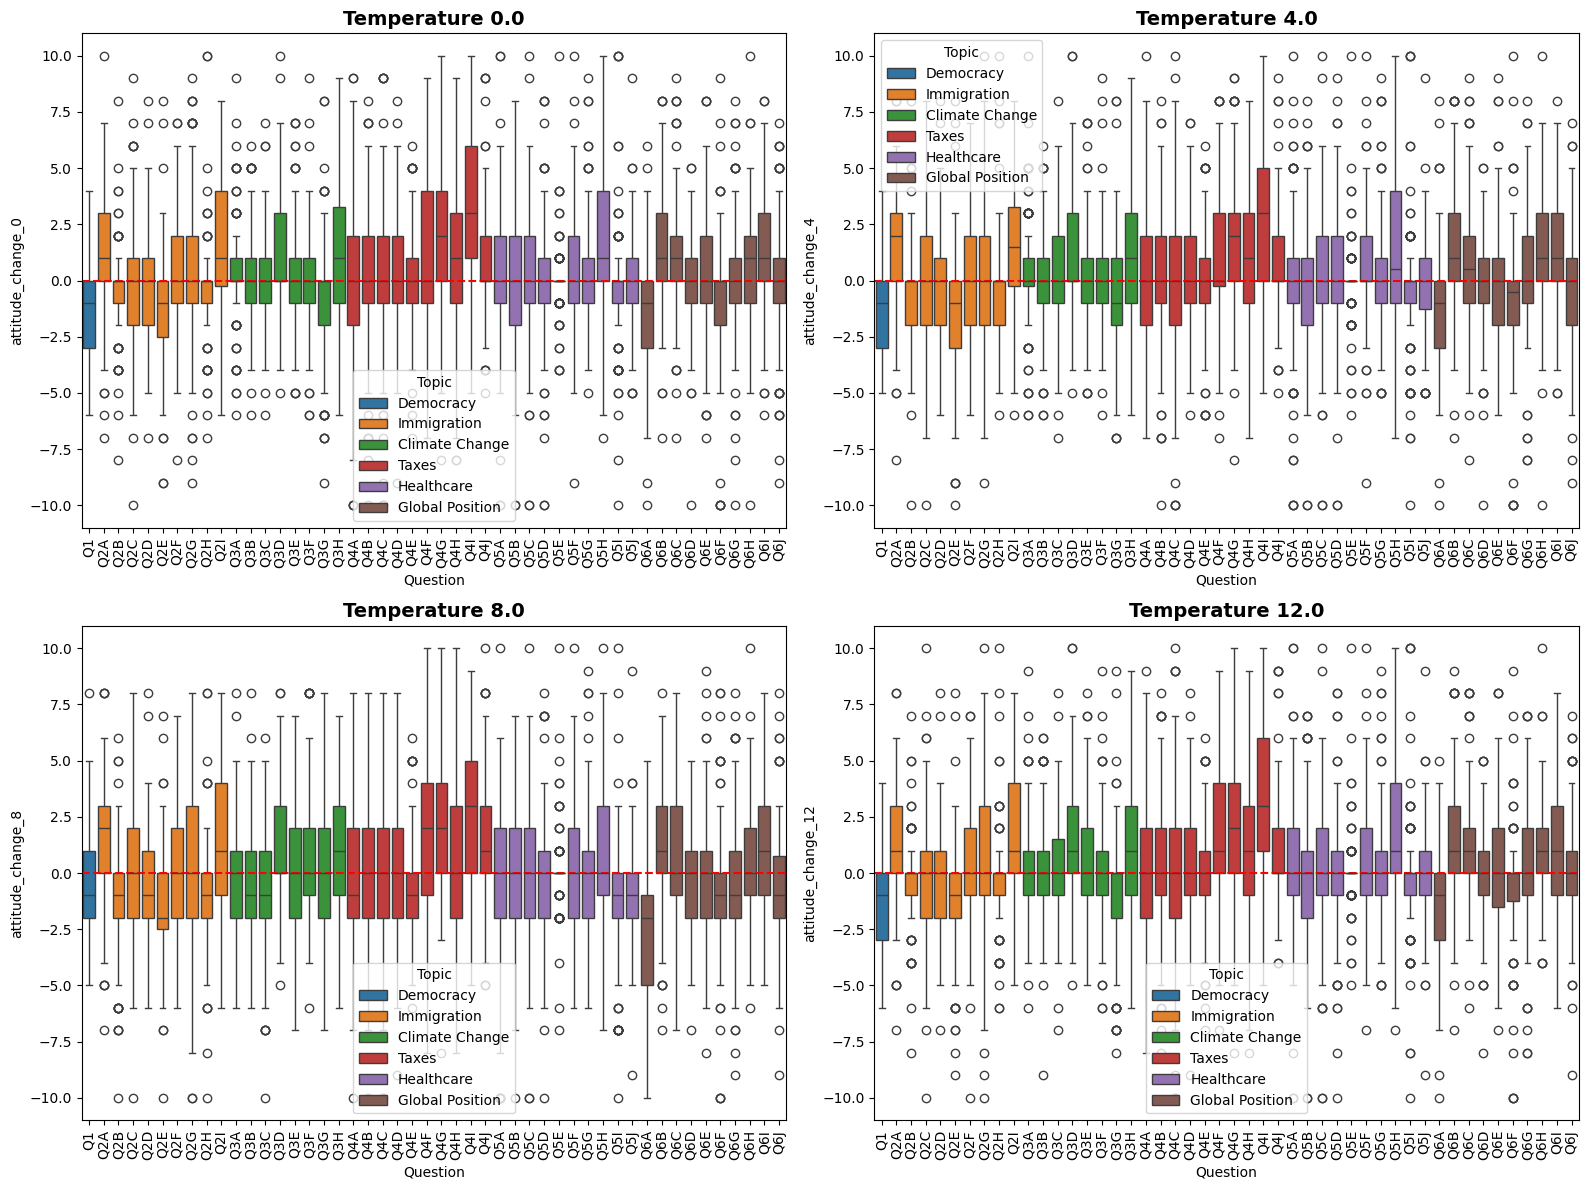

In [10]:
# i want subplots for each temperature
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
sns.boxplot(data=compare_df, x='Question', y='attitude_change_0', hue='Topic', ax=axs[0,0])
axs[0,0].set_title('Temperature 0.0', fontsize=14, fontweight='bold')
axs[0,0].axhline(0, color='red', linestyle='--')
sns.boxplot(data=compare_df, x='Question', y='attitude_change_4', hue='Topic', ax=axs[0,1])
axs[0,1].set_title('Temperature 4.0', fontsize=14, fontweight='bold')
axs[0,1].axhline(0, color='red', linestyle='--')
sns.boxplot(data=compare_df, x='Question', y='attitude_change_8', hue='Topic', ax=axs[1,0])
axs[1,0].set_title('Temperature 8.0', fontsize=14, fontweight='bold')
axs[1,0].axhline(0, color='red', linestyle='--')
sns.boxplot(data=compare_df, x='Question', y='attitude_change_12', hue='Topic', ax=axs[1,1])
axs[1,1].set_title('Temperature 12.0', fontsize=14, fontweight='bold')
axs[1,1].axhline(0, color='red', linestyle='--')
for ax in axs.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.tight_layout()

In [11]:
# for each question and temperature, calculate the mean attitude change and also the standard deviation
summary_stats = []
for question in questions:
    for temp in ['0', '4', '8', '12']:
        col_name = f'temp_{temp}'
        change = compare_df[compare_df['Question'] == question][col_name] - compare_df[compare_df['Question'] == question]['AfterNumber']
        mean_change = change.mean()
        mse_change = (change ** 2).mean()
        rmse_change = np.sqrt(mse_change)
        std_change = change.std()
        summary_stats.append({
            'Question': question,
            'Temperature': str(float(temp)/10),
            'MeanAttitudeChange': mean_change,
            'RMSEAttitudeChange': rmse_change,
            'StdAttitudeChange': std_change
        })
summary_df = pd.DataFrame(summary_stats)

In [12]:
summary_df.head()

,Question,Temperature,MeanAttitudeChange,RMSEAttitudeChange,StdAttitudeChange
0,Q3G,0.0,-0.848214,3.013363,2.904516
1,Q3G,0.4,-0.750000,3.082207,3.003002
2,Q3G,0.8,-0.508929,3.095215,3.066810
3,Q3G,1.2,-0.991071,3.103857,2.954598
4,Q4C,0.0,0.000000,3.629382,3.645128


/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_33334/1686169616.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=summary_df, x='Question', y='MeanAttitudeChange', hue='Temperature', ci=None)


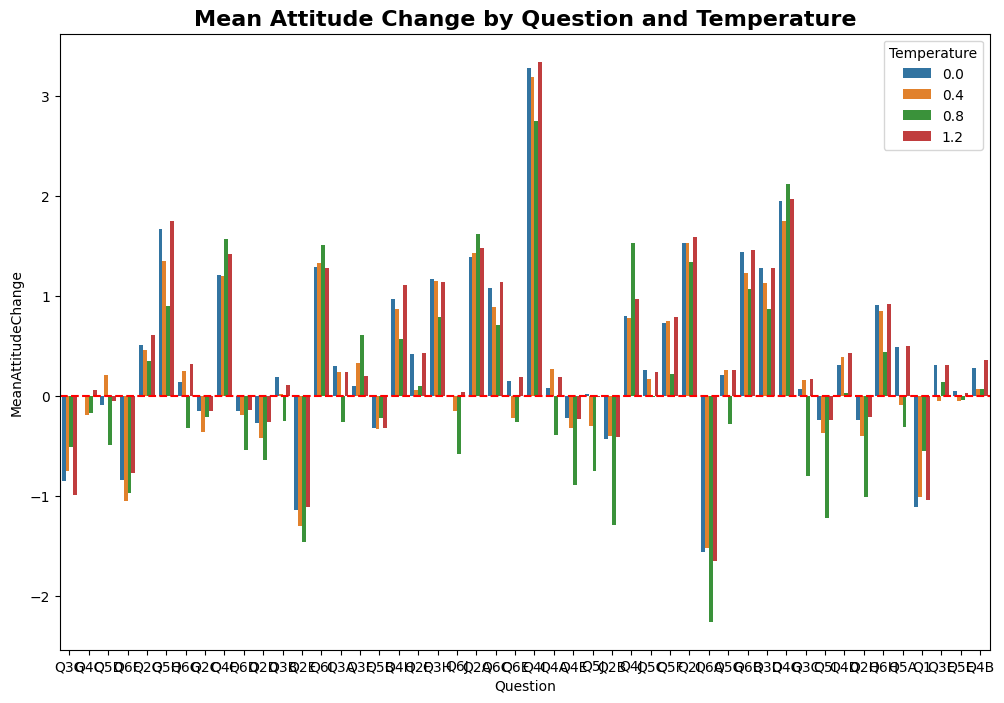

In [13]:
# for each question, plot the mean attitude change with error bars representing the standard deviation
# questions should be on the x axis and mean attitude change on the y axis
# coloured by temperature
plt.figure(figsize=(12, 8))
sns.barplot(data=summary_df, x='Question', y='MeanAttitudeChange', hue='Temperature', ci=None)
plt.title('Mean Attitude Change by Question and Temperature', fontsize=16, fontweight='bold')
plt.axhline(0, color='red', linestyle='--')

In [14]:
# for each question, find the temperature that resulted in the lowest mean attitude change
best_mean_temps = summary_df.loc[summary_df.groupby('Question')['MeanAttitudeChange'].idxmin()]
best_rmse_temps = summary_df.loc[summary_df.groupby('Question')['RMSEAttitudeChange'].idxmin()]

Text(0.5, 1.0, 'Best Temperature by RMSE Attitude Change')

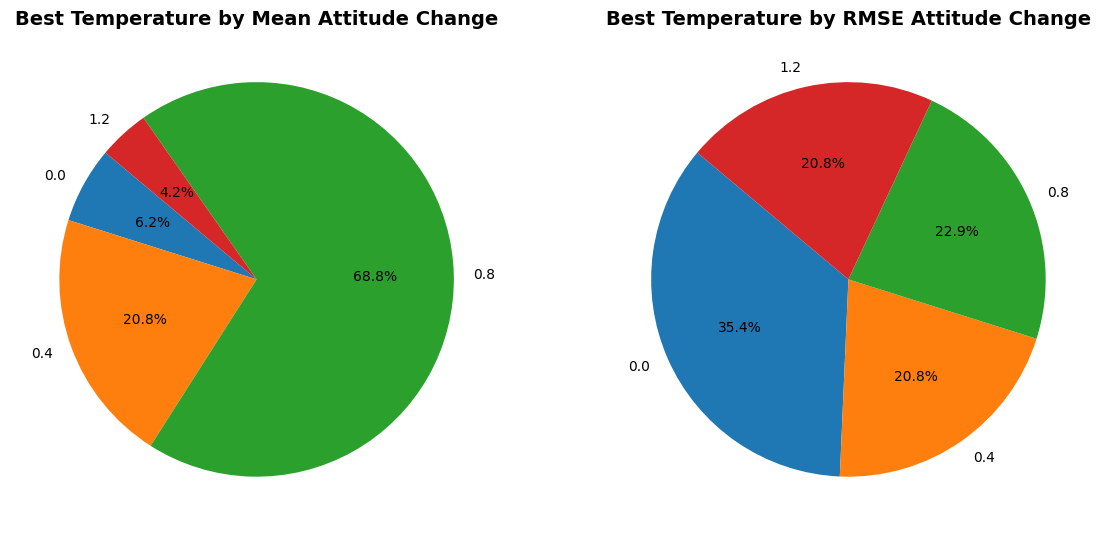

In [15]:
# plot these results as pie charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
best_mean_counts = best_mean_temps['Temperature'].value_counts().sort_index()
ax1.pie(best_mean_counts, labels=best_mean_counts.index, autopct='%1.1f%%', startangle=140)
ax1.set_title('Best Temperature by Mean Attitude Change', fontsize=14, fontweight='bold')
best_rmse_counts = best_rmse_temps['Temperature'].value_counts().sort_index()
ax2.pie(best_rmse_counts, labels=best_rmse_counts.index, autopct='%1.1f%%', startangle=140)
ax2.set_title('Best Temperature by RMSE Attitude Change', fontsize=14, fontweight='bold')

In [16]:
# i want to see how good the model is at predicting the after attitude for each temperature
prediction_stats = []
for temp in ['0', '4', '8', '12']:
    col_name = f'temp_{temp}'
    mean = (compare_df[col_name] - compare_df['AfterNumber']).mean()
    mse = np.mean((compare_df[col_name] - compare_df['AfterNumber']) ** 2)
    rmse = np.sqrt(mse)
    prediction_stats.append({
        'Temperature': temp,
        'Mean': mean,
        'MSE': mse,
        'RMSE': rmse
    })

prediction_df = pd.DataFrame(prediction_stats)

In [17]:
prediction_df.head()

,Temperature,Mean,MSE,RMSE
0,0,0.358974,8.234057,2.869505
1,4,0.273997,8.350592,2.889739
2,8,0.061966,8.848291,2.974608
3,12,0.397765,8.259040,2.873855


/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_33334/1156756816.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


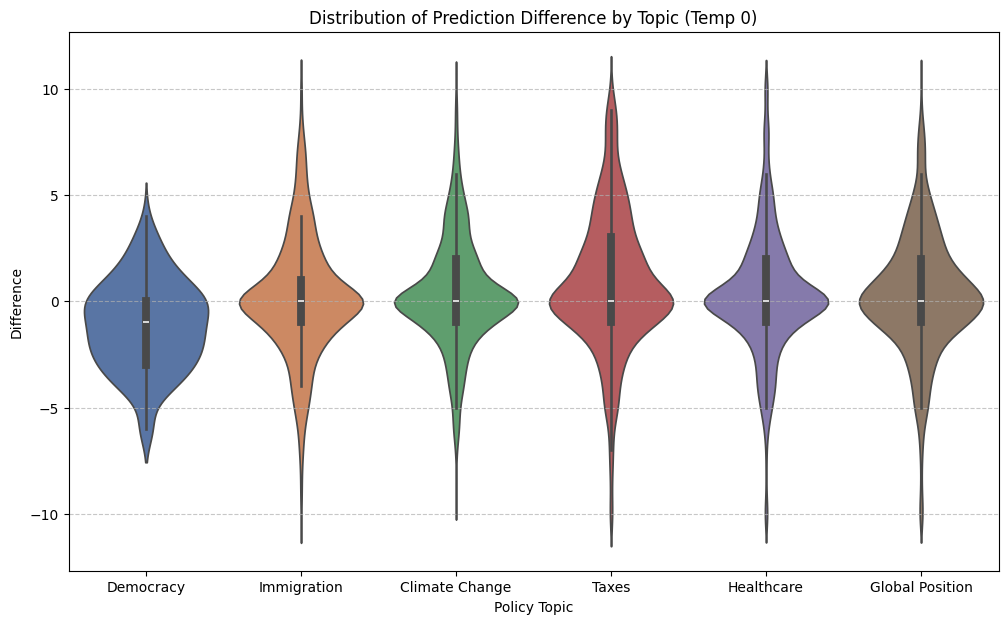

/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_33334/1156756816.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


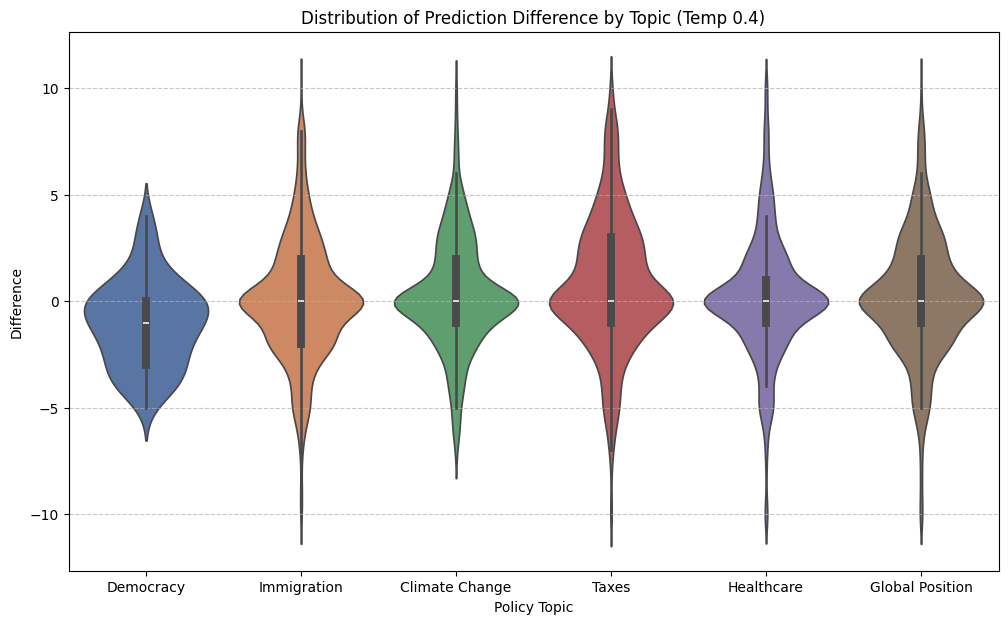

/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_33334/1156756816.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


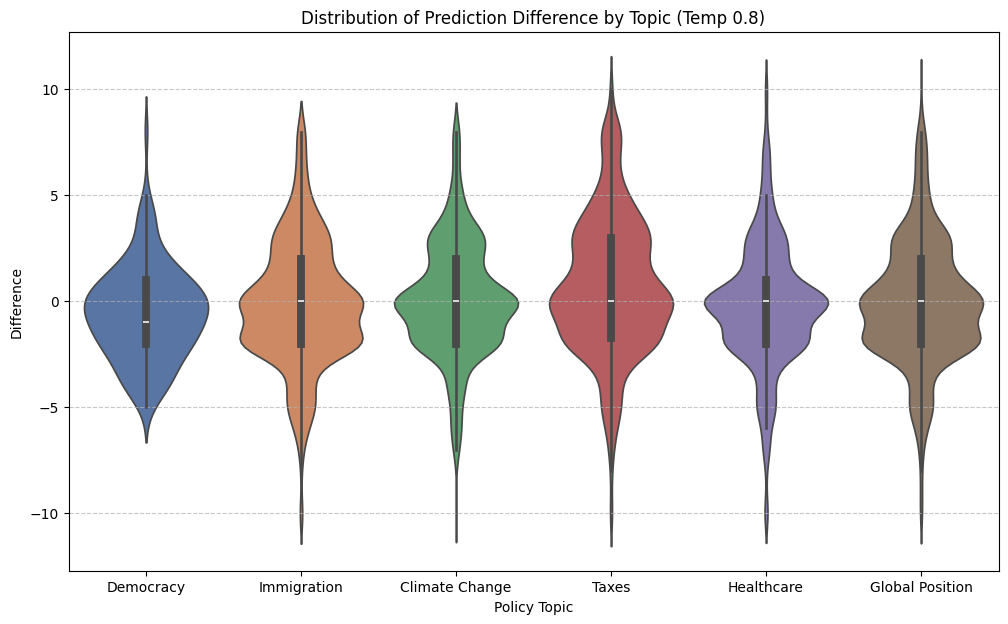

/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_33334/1156756816.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


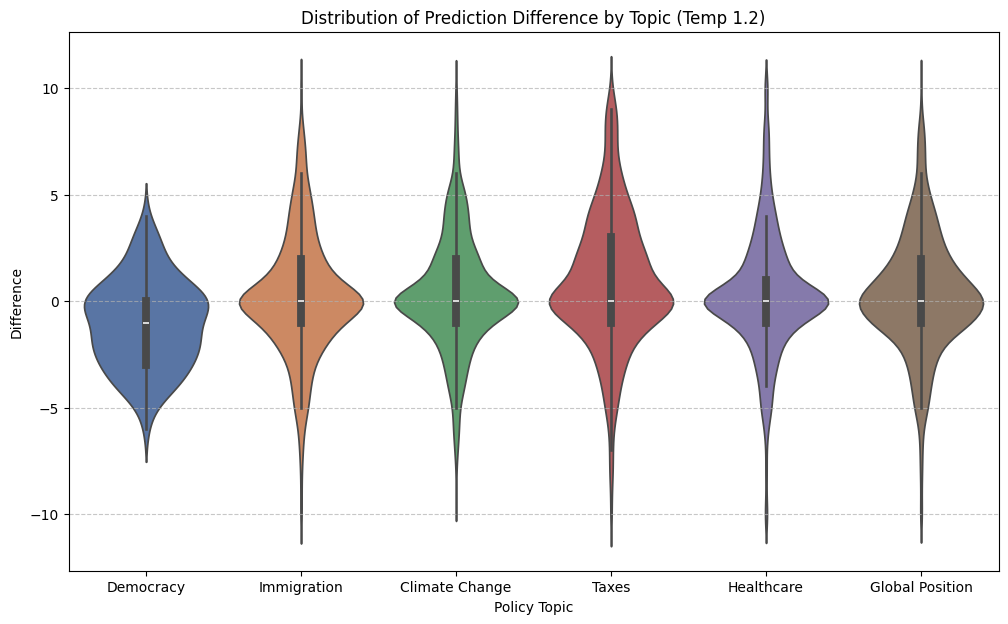

In [18]:
# Assuming your data is loaded into a Pandas DataFrame called 'df'
import seaborn as sns
import matplotlib.pyplot as plt

## do this and compare for each temperature
plt.figure(figsize=(12, 7))
sns.violinplot(
    x='Topic',
    y='attitude_change_0',
    data=compare_df,
    palette='deep'
)
plt.title('Distribution of Prediction Difference by Topic (Temp 0)')
plt.xlabel('Policy Topic')
plt.ylabel('Difference')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


plt.figure(figsize=(12, 7))
# Create the Box Plot
sns.violinplot(
    x='Topic',         # Use Topic as the categorical axis
    y='attitude_change_4',      # Use ABS_DIFF as the continuous distribution axis
    data=compare_df,
    palette='deep'     # Use a distinct color palette
)

plt.title('Distribution of Prediction Difference by Topic (Temp 0.4)')
plt.xlabel('Policy Topic')
plt.ylabel('Difference')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(12, 7))
# Create the Box Plot
sns.violinplot(
    x='Topic',         # Use Topic as the categorical axis
    y='attitude_change_8',      # Use ABS_DIFF as the continuous distribution axis
    data=compare_df,
    palette='deep'     # Use a distinct color palette
)

plt.title('Distribution of Prediction Difference by Topic (Temp 0.8)')
plt.xlabel('Policy Topic')
plt.ylabel('Difference')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(12, 7))
# Create the Box Plot
sns.violinplot(
    x='Topic',         # Use Topic as the categorical axis
    y='attitude_change_12',      # Use ABS_DIFF as the continuous distribution axis
    data=compare_df,
    palette='deep'     # Use a distinct color palette
)
plt.title('Distribution of Prediction Difference by Topic (Temp 1.2)')
plt.xlabel('Policy Topic')
plt.ylabel('Difference')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [19]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf
from sklearn.metrics import cohen_kappa_score

# df = pd.read_csv("your_data.csv") # Ensure data is loaded

results = []
questions = compare_df['Question'].unique()

for q in questions:
    question_plot_df = compare_df[compare_df['Question'] == q]
    real_data = question_plot_df["AfterNumber"]
    measurements = {}
    for temp in ["temp_0", "temp_4", "temp_8", "temp_12"]:
        sim_data = question_plot_df[temp]  # Change temp_X as needed

        # --- TEST 1: Paired Difference & Distribution ---
        try:
            # exact=False suppresses warnings for ties/zeros in large N
            w_stat, p_wilcox = stats.wilcoxon(real_data, sim_data)
        except ValueError:
            p_wilcox = 1.0

        try:
            kappa = cohen_kappa_score(real_data, sim_data, weights='quadratic')
        except:
            kappa = np.nan
            
        w_dist = stats.wasserstein_distance(real_data, sim_data)
        
        # Simple raw bias (Sim - Real)
        raw_bias = (sim_data - real_data).mean()
        raw_std = (sim_data - real_data).std()
        raw_rmse = np.sqrt(np.mean((sim_data - real_data) ** 2))


        # --- TEST 2: Demographic Alignment (Regression) ---
        real_df = question_plot_df.copy().drop(temp, axis=1)
        real_df.rename(columns={"AfterNumber": "Response"}, inplace=True)
        real_df['Is_Simulated'] = 0
        
        sim_df = question_plot_df.copy().drop("AfterNumber", axis=1)
        sim_df.rename(columns={temp: "Response"}, inplace=True)
        sim_df['Is_Simulated'] = 1
        
        question_regr_df = pd.concat([real_df, sim_df], ignore_index=True)
        
        # Base formula to check for systematic intercept shift (Bias)
        formula = "Response ~ C(RACE) + C(GENDER) + C(EDUCATION) + AGE + C(PARTYBEFORE) + Is_Simulated"

        try:
            model = smf.ols(formula, data=question_regr_df).fit(
                cov_type='cluster', 
                cov_kwds={'groups': question_regr_df['ID']}
            )
            sim_coef = model.params['Is_Simulated']
            sim_p_val = model.pvalues['Is_Simulated']
        except Exception as e:
            sim_coef, sim_p_val = np.nan, np.nan
        
        biasStr = temp + "_regression_bias"
        pValStr = temp + "_regression_pval"
        rawBiasStr = temp + "_bias"
        stdStr = temp + "_std"
        rmseStr = temp + "_rmse"
        wassersteinStr = temp + "_wasserstein"
        kappaStr = temp + "_kappa"
        wilcox = temp + "_wilcoxon_pval"

        measurements[rawBiasStr] = raw_bias # positive means simulated is higher
        measurements[stdStr] = raw_std # lower is better
        measurements[rmseStr] = raw_rmse # lower is better
        measurements[biasStr] = sim_coef # positive means simulated is higher
        measurements[pValStr] = sim_p_val # < 0.05 indicates significant bias
        measurements[wassersteinStr] = w_dist # lower is better
        measurements[kappaStr] = kappa # closer to 1 is better
        measurements[wilcox] = p_wilcox # < 0.05 indicates significant difference

    results.append({
        'Question': q,
        **measurements
    })
results_df = pd.DataFrame(results)
print(results_df.head())


  Question  temp_0_bias  temp_0_std  temp_0_rmse  temp_0_regression_bias  \
0       Q1    -1.111940    2.094247     2.364223               -1.111940   
1      Q2A     1.386364    2.593732     2.932317                1.386364   
2      Q2B    -0.431818    1.969978     2.009447               -0.431818   
3      Q2C    -0.147287    2.989829     2.981857               -0.147287   
4      Q2D    -0.272727    2.334902     2.341975               -0.272727   

   temp_0_regression_pval  temp_0_wasserstein  temp_0_kappa  \
0            2.038667e-09            1.111940      0.473216   
1            2.133509e-09            1.416667      0.559462   
2            1.407357e-02            0.431818      0.349009   
3            5.856289e-01            0.426357      0.362380   
4            1.907393e-01            0.393939      0.406397   

   temp_0_wilcoxon_pval  temp_4_bias  ...  temp_8_kappa  temp_8_wilcoxon_pval  \
0          4.897999e-08    -1.014925  ...      0.403268          1.527169e-03   
1 

In [20]:
# for each question, find the tempterature with the lowest wasserstein distance
best_wasserstein_temps = []
for index, row in results_df.iterrows():
    question = row['Question']
    wasserstein_values = {
        '0': row['temp_0_wasserstein'],
        '4': row['temp_4_wasserstein'],
        '8': row['temp_8_wasserstein'],
        '12': row['temp_12_wasserstein'],
    }
    best_temp = min(wasserstein_values, key=wasserstein_values.get)
    best_wasserstein_temps.append({
        'Question': question,
        'BestTemperature': best_temp,
        'WassersteinDistance': wasserstein_values[best_temp]
    })
best_wasserstein_df = pd.DataFrame(best_wasserstein_temps)
best_wasserstein_df.head()

,Question,BestTemperature,WassersteinDistance
0,Q1,8,0.731343
1,Q2A,0,1.416667
2,Q2B,12,0.409091
3,Q2C,12,0.341085
4,Q2D,0,0.393939


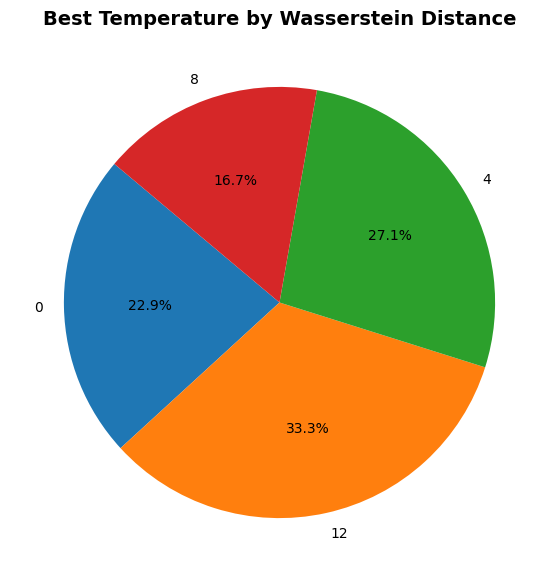

In [21]:
# pie chart of best temperatures by wasserstein distance
best_wasserstein_counts = best_wasserstein_df['BestTemperature'].value_counts().sort_index()
plt.figure(figsize=(7, 7))
plt.pie(best_wasserstein_counts, labels=best_wasserstein_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Best Temperature by Wasserstein Distance', fontsize=14, fontweight='bold')
plt.show()

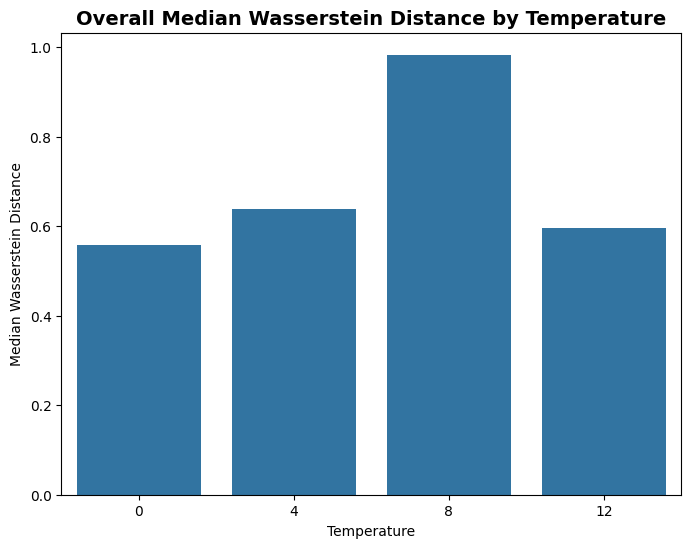

In [22]:
# for each temperature, calculate the overall median wasserstein distance
overall_wasserstein = {}
for temp in ['0', '4', '8', '12']:
    col_name = f'temp_{temp}_wasserstein'
    overall_wasserstein[temp] = results_df[col_name].median()
overall_wasserstein
# plot overall median wasserstein distances as a bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=list(overall_wasserstein.keys()), y=list(overall_wasserstein.values()))
plt.title('Overall Median Wasserstein Distance by Temperature', fontsize=14, fontweight='bold')
plt.xlabel('Temperature')
plt.ylabel('Median Wasserstein Distance')
plt.show()

In [23]:
sumdf = results_df.describe().reset_index()

In [24]:
results_df.to_csv("results/full_run_3/attitude_simulation_evaluation_by_question.csv", index=False)

In [25]:
results_df[['temp_0_regression_bias', 'temp_4_regression_bias', 'temp_8_regression_bias', 'temp_12_regression_bias']].median()

temp_0_regression_bias     0.198211
temp_4_regression_bias     0.162073
temp_8_regression_bias    -0.190858
temp_12_regression_bias    0.240015
dtype: float64

In [26]:
results_df[['temp_0_bias', 'temp_4__bias', 'temp_8_regression_bias', 'temp_12_regression_bias']].median()

KeyError: "['temp_4__bias'] not in index"

In [ ]:
sumdf

,index,temp_0_bias,temp_0_std,temp_0_rmse,temp_0_regression_bias,temp_0_regression_pval,temp_0_wasserstein,temp_0_kappa,temp_0_wilcoxon_pval,temp_4_bias,...,temp_8_kappa,temp_8_wilcoxon_pval,temp_12_bias,temp_12_std,temp_12_rmse,temp_12_regression_bias,temp_12_regression_pval,temp_12_wasserstein,temp_12_kappa,temp_12_wilcoxon_pval
0,count,48.000000,48.000000,48.000000,48.000000,4.800000e+01,48.000000,48.000000,4.800000e+01,48.000000,...,48.000000,4.800000e+01,48.000000,48.000000,48.000000,48.000000,4.800000e+01,48.000000,48.000000,4.800000e+01
1,mean,0.351920,2.692749,2.820815,0.351920,2.496302e-01,0.804452,0.505408,2.521686e-01,0.265950,...,0.408873,1.925117e-01,0.389308,2.689515,2.828760,0.389308,2.259352e-01,0.816610,0.494992,2.190446e-01
2,std,0.876979,0.462901,0.572881,0.876979,3.072390e-01,0.592836,0.140478,3.278193e-01,0.868525,...,0.145760,2.946179e-01,0.898129,0.445225,0.560889,0.898129,2.872249e-01,0.616844,0.137005,2.955855e-01
3,min,-1.564356,1.467272,1.462773,-1.564356,2.980400e-24,0.129032,0.141872,1.583963e-14,-1.524752,...,0.117265,3.119021e-13,-1.653465,1.563193,1.557713,-1.653465,9.159021e-27,0.072581,0.121891,3.934908e-15
4,25%,-0.147574,2.360940,2.376003,-0.147574,1.433961e-05,0.377961,0.411520,1.593905e-05,-0.304617,...,0.306098,7.909539e-06,-0.144228,2.371580,2.389657,-0.144228,3.315869e-06,0.380547,0.421505,7.326890e-06
5,50%,0.198211,2.716507,2.905712,0.198211,1.199007e-01,0.558844,0.502868,8.835495e-02,0.162073,...,0.432149,1.291950e-02,0.240015,2.686874,2.865051,0.240015,8.580520e-02,0.595403,0.488027,5.890136e-02
6,75%,0.922825,2.999743,3.064265,0.922825,3.876174e-01,1.118306,0.581683,5.274389e-01,0.856202,...,0.494288,2.998152e-01,1.002670,2.973718,3.072101,1.002670,3.582120e-01,1.132943,0.564882,3.713754e-01
7,max,3.280992,3.652790,4.754293,3.280992,1.000000e+00,3.280992,0.784758,9.957250e-01,3.181818,...,0.708743,9.663726e-01,3.338843,3.671959,4.709758,3.338843,9.674111e-01,3.338843,0.769309,9.884275e-01


In [ ]:
sumdf[['index', 'temp_0_wasserstein', 'temp_4_wasserstein', 'temp_8_wasserstein', 'temp_12_wasserstein']]

,index,temp_0_wasserstein,temp_4_wasserstein,temp_8_wasserstein,temp_12_wasserstein
0,count,48.000000,48.000000,48.000000,48.000000
1,mean,0.804452,0.818475,1.094890,0.816610
2,std,0.592836,0.550078,0.476018,0.616844
3,min,0.129032,0.198529,0.356061,0.072581
4,25%,0.377961,0.433340,0.792150,0.380547
5,50%,0.558844,0.638258,0.983223,0.595403
6,75%,1.118306,1.081885,1.285758,1.132943
7,max,3.280992,3.181818,2.776860,3.338843


In [ ]:
sumdf[['index', 'temp_0_kappa', 'temp_4_kappa', 'temp_8_kappa', 'temp_12_kappa']]

,index,temp_0_kappa,temp_4_kappa,temp_8_kappa,temp_12_kappa
0,count,48.000000,48.000000,48.000000,48.000000
1,mean,0.505408,0.485510,0.408873,0.494992
2,std,0.140478,0.137598,0.145760,0.137005
3,min,0.141872,0.124155,0.117265,0.121891
4,25%,0.411520,0.397721,0.306098,0.421505
5,50%,0.502868,0.498592,0.432149,0.488027
6,75%,0.581683,0.563708,0.494288,0.564882
7,max,0.784758,0.775571,0.708743,0.769309


In [ ]:
sumdf[['index', 'temp_0_bias', 'temp_4_bias', 'temp_8_bias', 'temp_12_bias']]

,index,temp_0_bias,temp_4_bias,temp_8_bias,temp_12_bias
0,count,48.000000,48.000000,48.000000,48.000000
1,mean,0.351920,0.265950,0.053370,0.389308
2,std,0.876979,0.868525,0.980191,0.898129
3,min,-1.564356,-1.524752,-2.257426,-1.653465
4,25%,-0.147574,-0.304617,-0.542357,-0.144228
5,50%,0.198211,0.162073,-0.190858,0.240015
6,75%,0.922825,0.856202,0.629946,1.002670
7,max,3.280992,3.181818,2.743802,3.338843


In [ ]:
sumdf[['index', 'temp_0_wilcoxon_pval', 'temp_4_wilcoxon_pval', 'temp_8_wilcoxon_pval', 'temp_12_wilcoxon_pval']]

,index,temp_0_wilcoxon_pval,temp_4_wilcoxon_pval,temp_8_wilcoxon_pval,temp_12_wilcoxon_pval
0,count,4.800000e+01,4.800000e+01,4.800000e+01,4.800000e+01
1,mean,2.521686e-01,2.079055e-01,1.925117e-01,2.190446e-01
2,std,3.278193e-01,2.705427e-01,2.946179e-01,2.955855e-01
3,min,1.583963e-14,1.525927e-14,3.119021e-13,3.934908e-15
4,25%,1.593905e-05,5.310335e-05,7.909539e-06,7.326890e-06
5,50%,8.835495e-02,4.689465e-02,1.291950e-02,5.890136e-02
6,75%,5.274389e-01,3.718039e-01,2.998152e-01,3.713754e-01
7,max,9.957250e-01,9.281142e-01,9.663726e-01,9.884275e-01


In [ ]:
compare_df['temp_0_len'] = compare_df['temp_0_arguments'].apply(len)
compare_df['temp_4_len'] = compare_df['temp_4_arguments'].apply(len)
compare_df['temp_8_len'] = compare_df['temp_8_arguments'].apply(len)
compare_df['temp_12_len'] = compare_df['temp_12_arguments'].apply(len)

In [ ]:
compare_df[['temp_0_len', 'temp_4_len', 'temp_8_len', 'temp_12_len']].describe()

,temp_0_len,temp_4_len,temp_8_len,temp_12_len
count,6084.000000,6084.000000,6084.000000,6084.000000
mean,802.054405,792.741946,891.433596,773.765122
std,273.458796,264.783181,249.378491,266.812676
min,219.000000,255.000000,26.000000,272.000000
25%,523.000000,538.750000,747.750000,520.000000
50%,967.000000,847.000000,1002.000000,751.000000
75%,1046.000000,1046.000000,1065.000000,1041.000000
max,1192.000000,1220.000000,2120.000000,1257.000000
